# CME Treasury Futures: Daily CTD and Implied Repo 2015-2025

## Outline

### Data used:
 - CME 10-year Treasury note futures quarterly contracts (ZN.H Mar, ZN.M Jun, ZN.U Sep, ZN.Z Dec), daily settlement prices from DataBento
 - CUSIP-level UST daily closing prices from FedInvest via TreasuryDirect

### Workflow for each trade day 2015-2025:
 - Pick "active" quarterly ZN contract, roll 5 trading days before delivery month starts
 - Build deliverable basket of Treasuries (remaining life 6.5y-8y from 1st day of delivery month)
 - Compute conversion factors for bonds deliverable basket
 - Compute implied repo and gross basis for each eligible bond, determine CTD

 ### Analysis:
 - Plot implied repo against SOFR as proxy for GC repo, 2015-2025


In [1]:
# read ZN quarterly contracts, drop other instruments (spreads etc)

import re
import numpy as np
import pandas as pd

START = pd.Timestamp("2015-01-01").date()
END = pd.Timestamp("2025-12-31").date()

OUTRIGHT_RE = re.compile(r"^ZN[HMUZ]\d{1,2}$")

USECOLS = ["ts_event", "ts_ref", "instrument_id", "symbol", "price", "stat_type", "sequence", "stat_flags"]

pieces = []


for chunk in pd.read_csv("CME_futures.csv", 
                        usecols=["ts_event", "ts_ref", "instrument_id", "symbol", "price", "stat_type", "sequence", "stat_flags"],
                        chunksize=2_000_000):
    chunk["ts_event"] = pd.to_datetime(chunk["ts_event"], utc=True, errors="coerce")
    chunk["ts_ref"] = pd.to_datetime(chunk["ts_ref"], utc=True, errors="coerce")

    chunk = chunk.dropna(subset=["ts_event", "symbol", "instrument_id"])
    chunk["stat_type"] = pd.to_numeric(chunk["stat_type"], errors="coerce")
    chunk = chunk[chunk["stat_type"]==3]

    # Keep only ZNH/ZNM/ZNU/ZNZ outrights
    sym = chunk["symbol"].astype(str)
    chunk = chunk[sym.str.match(OUTRIGHT_RE)]
    if chunk.empty:
        continue

    if chunk.empty:
        continue

    # Fallback: use ts_ref, impute empty rows with ts_event, with Sat/Sun shifted to Fri based on Chicago timezone
    chicago = chunk["ts_event"].dt.tz_convert("America/Chicago")
    event_day = chicago.dt.floor("D")
    wd = event_day.dt.weekday  # Mon=0, Sun=6

    # Shift weekend to Friday
    shift = np.where(wd == 5, 1, np.where(wd == 6, 2, 0))
    trade_day_fallback = (event_day - pd.to_timedelta(shift, unit="D")).dt.date

    # Use ts_ref date when present, otherwise fallback
    trade_day_ref = chunk["ts_ref"].dt.date
    chunk["trade_date"] = trade_day_ref.where(~chunk["ts_ref"].isna(), trade_day_fallback)

    chunk = chunk[(chunk["trade_date"] >= START) & (chunk["trade_date"] <= END)]

    chunk["sequence"] = pd.to_numeric(chunk["sequence"], errors="coerce").fillna(-1).astype("int64")
    chunk["price"] = pd.to_numeric(chunk["price"], errors="coerce")
    chunk = chunk.dropna(subset=["price"])

    pieces.append(chunk[["trade_date", "ts_event", "sequence", "instrument_id", "symbol", "price", "stat_flags"]])

df = pd.concat(pieces, ignore_index=True)
print("Filtered rows kept: ", len(df))


Filtered rows kept:  38553


In [2]:
# We now have all records of ZNH/ZNM/ZNU/ZNZ with stat_type==3 (settlement price)
# Next, dedupe: for each (instrument, date) pair, keep only most recent record (ts_event with sequence as tiebreaker)
df = df.sort_values(["instrument_id", "trade_date", "ts_event", "sequence"])
df = df.groupby(["trade_date", "instrument_id"], as_index=False).tail(1)

# Fix ambiguity in ZN5 (2015 vs 2025) by building 2-digit contract code
df["trade_date_dt"] = pd.to_datetime(df["trade_date"])  # easier for group ops

# For each instrument_id, assume contract year = max trade_date year seen for that instrument
df["contract_year"] = df.groupby("instrument_id")["trade_date_dt"].transform("max").dt.year

# Month code is the third character of symbol: ZN[H/M/U/Z]...
df["month_code"] = df["symbol"].str[2]

# Unambiguous contract code: e.g. ZNH15, ZNM20, ZNZ24, ZNH25
df["contract_code"] = (
    "ZN" + df["month_code"] + (df["contract_year"] % 100).astype(int).astype(str).str.zfill(2)
)

# Root series names: ZNH / ZNM / ZNU / ZNZ
df["root"] = df["contract_code"].str[:3]

# Final tidy output
out = df[["trade_date", "contract_code", "root", "instrument_id", "price", "stat_flags"]].rename(
    columns={"price": "settle"}
).sort_values(["trade_date", "contract_code"])

# out.to_csv("ZN_quarterly_settlements_2015_2025_clean.csv", index=False)

# for root in ["ZNH", "ZNM", "ZNU", "ZNZ"]:
#     out[out["root"] == root].to_csv(f"{root}_settlements_2015_2025_clean.csv", index=False)

futures_settle = out.copy()

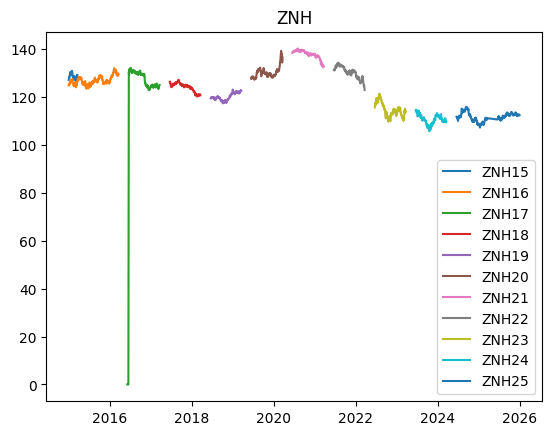

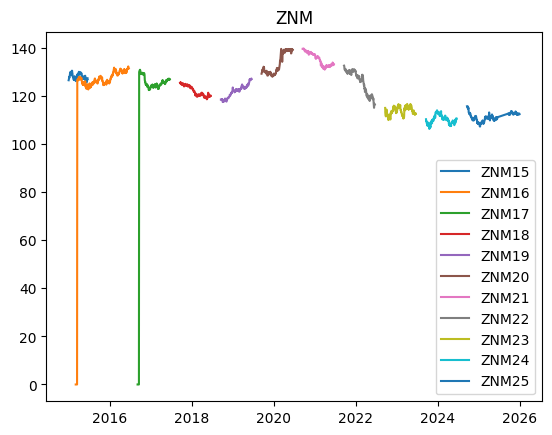

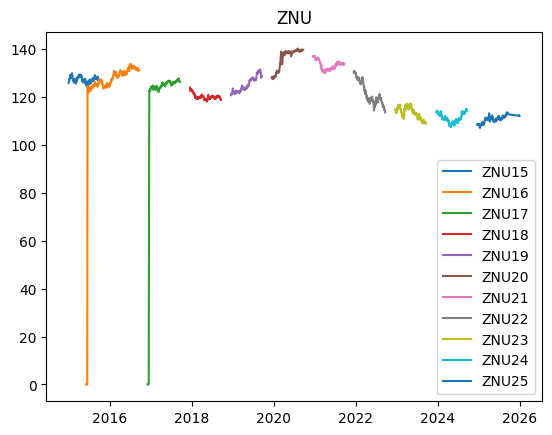

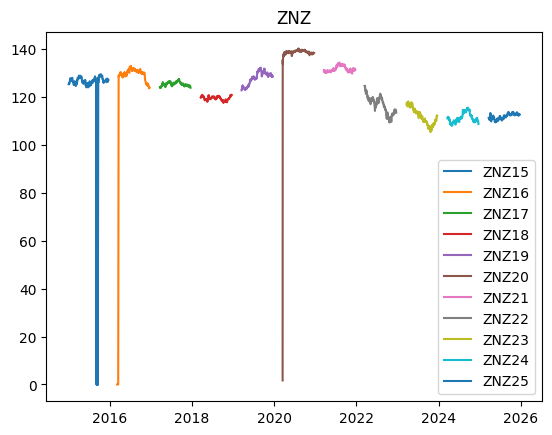

In [3]:
import matplotlib.pyplot as plt

# check that time series look OK

for symbol in ["H","M","U","Z"]:
    contract = "ZN" + symbol
    plot_df = out[out["root"]==contract]
    for contract_code, group in plot_df.groupby("contract_code"):
        plt.plot(group["trade_date"], group["settle"], label=contract_code)
    plt.title(contract)
    plt.legend()
    plt.show()

In [4]:
# Donwload repo rates

from pathlib import Path
import requests
import io

def fetch_repo_series(cache_dir: Path) -> pd.Series:
    """
    Returns a daily repo proxy series (percent):
      - Primary Dealer Survey GC Repo Rate through 2018-02-28 (NY Fed xlsx)
      - SOFR from FRED afterward
    """
    cache_dir.mkdir(parents=True, exist_ok=True)

    # 1) PD Survey file (xlsx)
    pd_path = cache_dir / "HistoricalOvernightTreasGCRepoPriDealerSurvRate.xlsx"
    if not pd_path.exists():
        url = "https://www.newyorkfed.org/medialibrary/media/markets/HistoricalOvernightTreasGCRepoPriDealerSurvRate.xlsx"
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        pd_path.write_bytes(r.content)

    pd_df = pd.read_excel(pd_path, sheet_name=0)
    pd_df.columns = ["date", "repo"]
    pd_df["date"] = pd.to_datetime(pd_df["date"])
    pd_df["repo"] = pd.to_numeric(pd_df["repo"], errors="coerce")
    pd_repo = pd_df.set_index("date")["repo"]

    # 2) SOFR from FRED CSV
    # Works without API key in most environments.
    sofr_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=SOFR"
    r = requests.get(sofr_url, timeout=30)
    r.raise_for_status()
    sofr_df = pd.read_csv(io.StringIO(r.text))
    sofr_df.columns = ["date", "repo"]
    sofr_df["date"] = pd.to_datetime(sofr_df["date"])
    sofr_df["repo"] = pd.to_numeric(sofr_df["repo"], errors="coerce")
    sofr_repo = sofr_df.set_index("date")["repo"]

    repo = pd.concat([pd_repo, sofr_repo]).sort_index()
    return repo


repo = fetch_repo_series(Path("cache"))

repo_df = repo.reset_index()
repo_df.columns = ["Date", "repo"]

In [5]:
# ZN contract class

from dataclasses import dataclass

@dataclass(frozen=True)
class ZNContract:
    code: str
    month: int
    year: int
    delivery_month_start: dt.date
    last_trading_day: dt.date


In [6]:
basis_1st_quarter = pd.DataFrame(columns=["Date", "Active_contract", "Futures_settle", "CTD_price", "CTD_CUSIP", "CTD_name", "CTD_IR", 
                                   "Repo_proxy", "Gross_basis", "Net_basis"])

In [7]:

# Date helpers

import math
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay
US_BDAY = CustomBusinessDay(calendar=USFederalHolidayCalendar())

def first_business_day_on_or_after(ts: pd.Timestamp):
    if ts.weekday() >= 5 or ts in USFederalHolidayCalendar().holidays(ts, ts):
        # Move forward to next business day
        ts2 = ts
        while True:
            ts2 = ts2 + pd.Timedelta(days=1)
            if ts2.weekday() < 5 and ts2 not in USFederalHolidayCalendar().holidays(ts2, ts2):
                return ts2
    return ts


# Coupon helpers

def round_coupon_to_nearest_1_8_percent(coupon_decimal: float):
    """
    CME: coupon in decimals rounded to nearest one-eighth of one percent (ties rounded up).
    1/8 of 1% = 0.125% = 0.00125 in decimal.
    """
    step = 0.00125
    x = coupon_decimal / step
    flo = math.floor(x)
    frac = x - flo
    if frac > 0.5:
        return (flo + 1) * step
    if frac < 0.5:
        return flo * step
    # tie
    return (flo + 1) * step

def last_next_coupon_dates(maturity: dt.date, asof: dt.date) -> Tuple[dt.date, dt.date]:
    """
    For a Treasury with semiannual coupons on maturity day-of-month,
    walk backward from maturity in 6M steps to find last <= asof < next.
    """
    nxt = maturity
    while True:
        prev = nxt - relativedelta(months=6)
        if prev <= asof < nxt:
            return prev, nxt
        nxt = prev

def accrued_interest(coupon_decimal: float, maturity: dt.date, asof: dt.date) -> float:
    last_cpn, next_cpn = last_next_coupon_dates(maturity, asof)
    period_days = (next_cpn - last_cpn).days
    if period_days <= 0:
        return 0.0
    accr_days = (asof - last_cpn).days
    accr_days = max(accr_days, 0)
    return (coupon_decimal / 2) * 100.0 * (accr_days / period_days)


def coupon_cashflows_between(coupon_decimal: float, maturity: dt.date, start_excl: dt.date, end_incl: dt.date) -> float:
    """
    Sum coupons paid in (start_excl, end_incl].
    """
    amt = (coupon_decimal / 2) * 100.0
    total = 0.0
    d = maturity
    # walk backwards
    while d > start_excl:
        if start_excl < d <= end_incl:
            total += amt
        d = d - relativedelta(months=6)
    return total

In [8]:
# Determine active front-month contract of any given trade date
import datetime as dt

# def determine_active_ZN_contract(date: dt.date): 
#     d = pd.Timestamp(date)

#     for year in [d.year, d.year + 1]:
#         for month in [3, 6, 9, 12]:
#             month_end = pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)
#             last_trading_day = month_end - pd.offsets.BDay(7)   # day prior to last 7 biz days 

#             if last_trading_day >= d:
#                 active_contract = ZNContract(code = "ZN" + {3: "H", 6: "M", 9: "U", 12: "Z"}[month] + f"{year % 100:02d}",
#                                              month=month,
#                                              year=year,
#                                              delivery_month_start = pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthBegin(0),
#                                              last_trading_day=last_trading_day)
#                 return active_contract



# determine_active_ZN_contract(dt.date(2026,12,23))


MONTH_CODE = {3: "H", 6: "M", 9: "U", 12: "Z"}

def determine_active_ZN_contract(date: dt.date) -> ZNContract:

    d = pd.Timestamp(date)

    for year in [d.year, d.year + 1]:
        for month in [3, 6, 9, 12]:
            delivery_month_start = pd.Timestamp(year=year, month=month, day=1)

            # Roll 5d before delivery month starts
            roll_date = delivery_month_start - pd.offsets.BDay(5)

            month_end = delivery_month_start + pd.offsets.MonthEnd(0)
            last_trading_day = month_end - pd.offsets.BDay(8)

            if d <= roll_date:
                code = "ZN" + MONTH_CODE[month] + f"{year % 100:02d}"
                return ZNContract(
                    code=code,
                    month=month,
                    year=year,
                    delivery_month_start=delivery_month_start.date(),
                    last_trading_day=last_trading_day.date(),
                )

    raise ValueError(f"No contract found for {date}")

In [9]:
def conversion_factor(coupon_decimal: float, maturity: dt.date, delivery_month_start: dt.date):
    # Based on https://www.cmegroup.com/trading/interest-rates/files/Calculating_U.S.Treasury_Futures_Conversion_Factors.pdf
    
    coupon = round_coupon_to_nearest_1_8_percent(coupon_decimal)

    rd = relativedelta(maturity, delivery_month_start)
    n = rd.years
    months = rd.months

    z = (months // 3) * 3

    if z < 7:
        v = z
        c = 1 / (1.03 ** (2 * n))
    else:
        v = 3
        c = 1 / (1.03 ** (2 * n + 1))

    a = 1 / (1.03 ** (v / 6))
    b = (coupon / 2) * (6 - v) / 6
    d = (coupon / 0.06) * (1 - c)

    factor = a * ((coupon / 2) + c + d) - b
    return round(factor, 4)


In [10]:
from dateutil.relativedelta import relativedelta

def get_deliverable_basket(contract: ZNContract, day: dt.date):
    #day = first_business_day_on_or_after(pd.Timestamp(day))
    day = pd.Timestamp(day)
    day_str = day.strftime("%Y-%m-%d")
    df = pd.read_csv(
        f"fedinvest_prices/{day_str}.csv.gz", compression="gzip"
    )
    df = df.dropna(subset=["cusip", "rate", "maturity_date", "eod_price"])
    df["maturity_date"] = pd.to_datetime(df["maturity_date"]).dt.date

    # data already filtered for TIPS, floaters, bills
    # filter out "MARKET BASED BOND", only notes
    st = df["security_type"].astype(str).str.lower()
    df = df[st.str.contains("note", na=False)]

    # filter by remaining life: 6.5 to 8 years from start of delivery month
    start = contract.delivery_month_start
    low = start + relativedelta(years=6, months=6)
    high = start + relativedelta(years=8)

    df = df[(df["maturity_date"] >= low) & (df["maturity_date"] <= high)]

    df["cf"] = df.apply(lambda row: conversion_factor(row["rate"], row["maturity_date"], start), axis=1)
    
    return df[["date", "cusip", "security_type", "rate", "maturity_date", "bid", "offer", "eod_price", "cf"]]

Sanity check: deliverable basket and conversion factors agree with table form CME website:

![alt text](basket.png)

In [11]:

get_deliverable_basket(determine_active_ZN_contract(dt.date(2026,1,1)), dt.date(2026,3,20))

,date,cusip,security_type,rate,maturity_date,bid,offer,eod_price,cf
221,2026-03-20,91282CNZ0,MARKET BASED NOTE,0.03875,2032-09-30,98.265625,98.25000,98.31250,0.8870
222,2026-03-20,91282CPF2,MARKET BASED NOTE,0.03750,2032-10-31,97.453125,97.43750,97.53125,0.8804
223,2026-03-20,91282CFV8,MARKET BASED NOTE,0.04125,2032-11-15,99.625000,99.59375,99.65625,0.9003
224,2026-03-20,91282CPM7,MARKET BASED NOTE,0.03750,2032-11-30,97.421875,97.40625,97.46875,0.8804
225,2026-03-20,91282CPQ8,MARKET BASED NOTE,0.03875,2032-12-31,98.093750,98.09375,98.12500,0.8834
226,2026-03-20,91282CPY1,MARKET BASED NOTE,0.04000,2033-01-31,98.796875,98.78125,98.84375,0.8902
227,2026-03-20,91282CGM7,MARKET BASED NOTE,0.03500,2033-02-15,95.781250,95.75000,95.81250,0.8628
228,2026-03-20,91282CQC8,MARKET BASED NOTE,0.03750,2033-02-28,97.265625,97.25000,97.31250,0.8765
229,2026-03-20,91282CHC8,MARKET BASED NOTE,0.03375,2033-05-15,94.781250,94.75000,94.81250,0.8517
230,2026-03-20,91282CHT1,MARKET BASED NOTE,0.03875,2033-08-15,97.687500,97.65625,97.71875,0.8765


In [12]:
# calculate implied repo based on futures settle, bond specs (clean price, cpn, maturity, cf)

def implied_repo(futures_settle: float,
                 contract: ZNContract,
                 bond_price_clean: float,
                 coupon_decimal: float,
                 maturity: dt.date,
                 cf: float,
                 val_date: dt.date):
    
    delivery_date = (contract.last_trading_day + pd.offsets.BMonthEnd(0)).date()
    ai_now = accrued_interest(coupon_decimal, maturity, val_date)
    bond_price_dirty = bond_price_clean + ai_now

    ai_delivery = accrued_interest(coupon_decimal, maturity, delivery_date)

    coupons = coupon_cashflows_between(coupon_decimal, maturity, val_date, delivery_date)

    days = (delivery_date - val_date).days

    next_cpn = last_next_coupon_dates(maturity, val_date)[1]
    days_cpn_to_deliv = (delivery_date - last_next_coupon_dates(maturity, val_date)[1]).days
    #print("next cpn"+str(next_cpn))

    invoice = futures_settle * cf + ai_delivery

    irr = (invoice + coupons - bond_price_dirty) * 360 /(bond_price_dirty * days - coupons*days_cpn_to_deliv) * 100
    irr_raw = (invoice + coupons) / bond_price_dirty - 1.0
    gross_basis = bond_price_clean - futures_settle*cf

    # We have two ways of calculating interest earned: either physical coupons plus change in AI, or simply 100*coupon_decimal/2*(days/181)
    interest_earned = coupons + ai_delivery - ai_now 
    #print("Interest earned: " + str(interest_earned))
    #print("C/2*days: "+ str(100*coupon_decimal/2*(days/181)))

    repo_rate = repo_df.loc[repo_df["Date"].dt.normalize()==pd.Timestamp(val_date),"repo"]

    if repo_rate.empty:
        net_basis = None
    else:
        repo_rate = float(repo_rate.iloc[0])/100
        repo_cost = bond_price_dirty*repo_rate*days/360
        carry_to_delivery = interest_earned + repo_cost
        net_basis = gross_basis - carry_to_delivery

    roll_date = (pd.Timestamp(contract.delivery_month_start) - pd.offsets.BDay(5)).date()

    return {
        "irr": irr,
        "invoice": invoice,
        "coupons": coupons,
        "bond_price_dirty": bond_price_dirty,
        "days": days,
        "gross_basis": gross_basis,
        "net_basis": net_basis,
        "raw": irr_raw,
        "roll_date": roll_date
    }

    

In [13]:
testvaldate = dt.date(2021,1,1)
repo_rate = repo_df.loc[repo_df["Date"].dt.normalize()==pd.Timestamp(testvaldate),"repo"]
repo_rate.empty


False

In [14]:
# Test functions on single date

today = dt.date(2024,9,9)

contract_today = determine_active_ZN_contract(today)
print(contract_today)

fut = futures_settle.loc[(futures_settle["contract_code"]==contract_today.code) &
                           (futures_settle["trade_date"]==today), "settle"].iloc[0]

basket = get_deliverable_basket(contract_today, today)
basket["irr"] = basket.apply(lambda row: implied_repo(fut, contract_today, row["eod_price"], row["rate"], row["maturity_date"],
                                                      row["cf"], today)["irr"], axis=1)
ctd = basket.loc[basket["irr"].idxmax()]
print("ctd irr:")
implied_repo(fut, contract_today, ctd["eod_price"], ctd["rate"], ctd["maturity_date"], ctd["cf"], today)


ZNContract(code='ZNZ24', month=12, year=2024, delivery_month_start=datetime.date(2024, 12, 1), last_trading_day=datetime.date(2024, 12, 19))
ctd irr:


{'irr': np.float64(4.913776561625256),
 'invoice': np.float64(104.34768676167583),
 'coupons': np.float64(2.125),
 'bond_price_dirty': np.float64(104.85570355191257),
 'days': 113,
 'gross_basis': np.float64(-0.30476093750000643),
 'net_basis': np.float64(-3.374539560799237),
 'raw': np.float64(0.015421032475956054),
 'roll_date': datetime.date(2024, 11, 25)}

In [15]:
# Collect results
basis_1st_quarter = pd.DataFrame(columns=["Date", "Active_contract", "Futures_settle", "CTD_price", "CTD_CUSIP", "CTD_name", "CTD_IR", 
                                   "Repo_proxy", "Gross_basis", "Net_basis"])

basis_1st_quarter["Date"] = pd.date_range(start="2015-01-02", end="2025-12-31")
for i, row in basis_1st_quarter.iterrows():
    day = row["Date"].date()

    if day.month == 12 and day.day == 31: print(str(day.year) + " done")

    active_contract = determine_active_ZN_contract(day)
    basis_1st_quarter.loc[i, "Active_contract"] = active_contract.code
    
    settle = futures_settle.loc[(futures_settle["contract_code"]==active_contract.code) &
                            (futures_settle["trade_date"]==day), "settle"]
    
    if settle.empty:
        continue
    settle = settle.iloc[0]
    basis_1st_quarter.loc[i, "Futures_settle"] = settle
    
    try:
        basket = get_deliverable_basket(active_contract, day)
    except FileNotFoundError:
        continue

    implied_repos = basket.apply(lambda row: implied_repo(settle, active_contract, row["eod_price"], row["rate"], row["maturity_date"],
                                                      row["cf"], day), axis=1)
    basket[["irr", "gross_basis", "raw", "net_basis"]] = pd.DataFrame(implied_repos.tolist(), index=basket.index)[["irr", "gross_basis", "raw", "net_basis"]]

    # basket["irr"] = basket.apply(lambda row: implied_repo(settle, active_contract, row["eod_price"], row["rate"], row["maturity_date"],
    #                                                   row["cf"], day)["irr"], axis=1)
    # basket["gross_basis"] = basket.apply(lambda row: implied_repo(settle, active_contract, row["eod_price"], row["rate"], row["maturity_date"],
    #                                                   row["cf"], day)["gross_basis"], axis=1)
    # basket["raw"] = basket.apply(lambda row: implied_repo(settle, active_contract, row["eod_price"], row["rate"], row["maturity_date"],
    #                                                   row["cf"], day)["raw"], axis=1)

    ctd = basket.loc[basket["irr"].idxmax()]
    basis_1st_quarter.loc[i, "CTD_CUSIP"] = ctd["cusip"]
    basis_1st_quarter.loc[i, "CTD_name"] = str(round(ctd["rate"]*100,3))+"% "+str(ctd["maturity_date"])
    basis_1st_quarter.loc[i, "CTD_IR"] = ctd["irr"]
    basis_1st_quarter.loc[i, "CTD_price"] = ctd["eod_price"]
    basis_1st_quarter.loc[i, "Gross_basis"] = ctd["gross_basis"]
    basis_1st_quarter.loc[i, "Net_basis"] = ctd["net_basis"]
    basis_1st_quarter.loc[i, "IR_raw"] = ctd["raw"]


2015 done
2016 done
2017 done
2018 done
2019 done
2020 done
2021 done
2022 done
2023 done
2024 done
2025 done


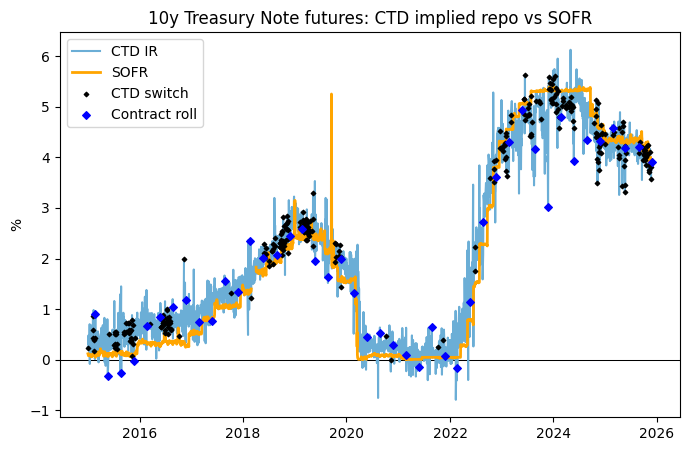

In [16]:
# Plotting

import seaborn as sns

basis_1st_quarter = basis_1st_quarter.dropna(subset="Futures_settle")
basis_1st_quarter["CTD_switch"] = (basis_1st_quarter["CTD_CUSIP"]!=basis_1st_quarter["CTD_CUSIP"].shift(-1))
basis_1st_quarter["Contract_switch"] = (basis_1st_quarter["Active_contract"]!=basis_1st_quarter["Active_contract"].shift(-1))

basis_1st_quarter = basis_1st_quarter.merge(repo_df[["Date", "repo"]],
                                            on="Date",
                                            how="left")

plot_df = basis_1st_quarter
plot_df["Date"] = pd.to_datetime(plot_df["Date"])

plot_df["Contract"] = plot_df["Active_contract"].str[2].map({
    "H": "Mar",
    "M": "Jun",
    "U": "Sep",
    "Z": "Dec"
})
plot_df["segment"] = (plot_df["Contract"] != plot_df["Contract"].shift()).cumsum()

blues = ["#78a1d6", "#4882c5", "#166fff", "#041030"]
blues = ["#9ecae1", "#6baed6", "#4292c6", "#2171b5"]

plt.figure(figsize=(8,5))
# sns.lineplot(
#     data=plot_df,
#     x="Date",
#     y="CTD_IR",
#     hue="Contract",
#     units="segment",
#     estimator=None,
#     palette=blues
# )

plt.axhline(0, color="black", linewidth=0.75)
plt.plot(plot_df["Date"], plot_df["CTD_IR"], label="CTD IR", color="#6baed6", linewidth=1.5)
plt.plot(plot_df["Date"], plot_df["repo"], label="SOFR", color="orange", linewidth=2)

CTD_switches = plot_df[plot_df["CTD_switch"] == True]
plt.scatter(
    CTD_switches["Date"],
    CTD_switches["CTD_IR"],
    marker="D",
    s=5,
    color="black",
    zorder=10,
    label="CTD switch"
)

Contract_switches = plot_df[plot_df["Contract_switch"] == True]
plt.scatter(
    Contract_switches["Date"],
    Contract_switches["CTD_IR"],
    marker="D",
    s=15,
    color="blue",
    zorder=10,
    label="Contract roll"
)

plt.xlabel("")
plt.ylabel("%")
plt.legend()
plt.title("10y Treasury Note futures: CTD implied repo vs SOFR")
plt.show()